In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Load master dataset
master = pd.read_csv("data/master_raw.csv", 
                      index_col='date', 
                      parse_dates=True)

# Forward fill the 1-2 missing values
master = master.ffill()

print(f"Dataset loaded: {len(master)} rows")
print(f"Date range: {master.index.min().date()} → {master.index.max().date()}")
print(f"\nNulls after fill: {master.isnull().sum().sum()}")

Dataset loaded: 4050 rows
Date range: 2010-01-04 → 2026-03-25

Nulls after fill: 0


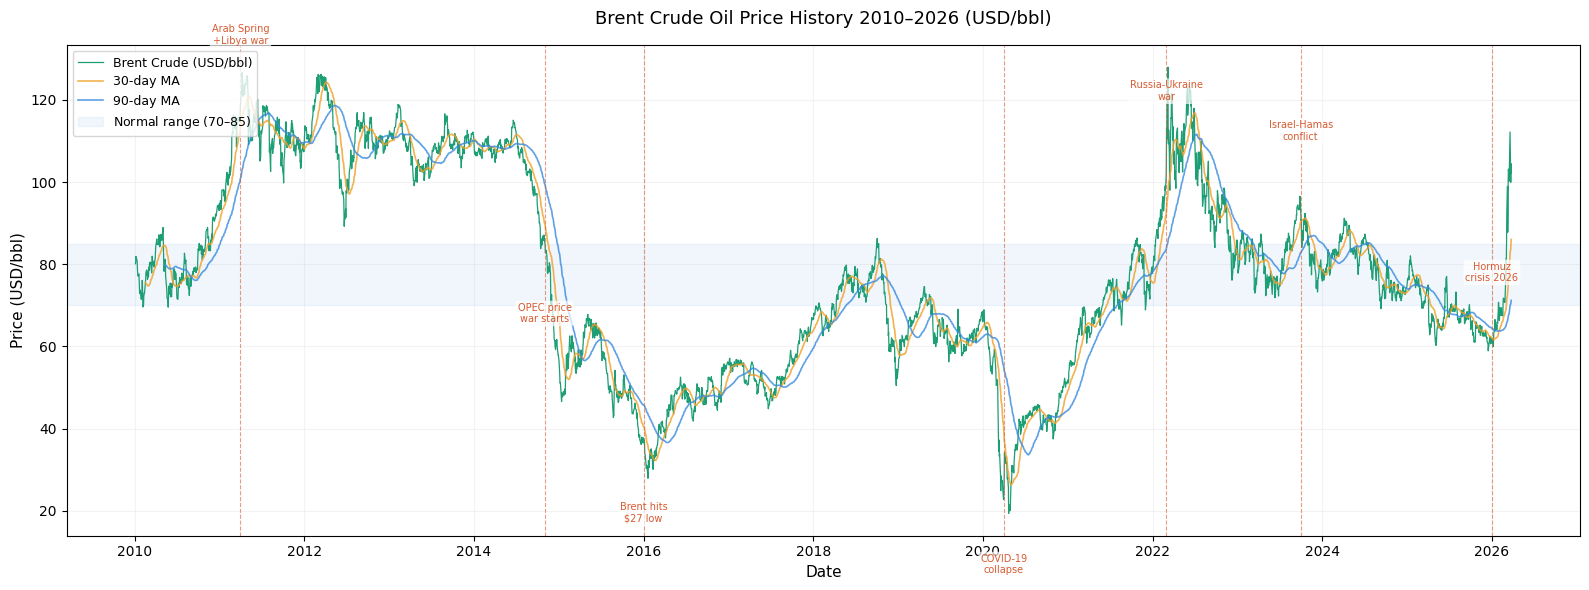

Chart 1 saved.


In [4]:
# Define your colour palette (batik-inspired, oil-themed)
C_GREEN  = '#1D9E75'
C_AMBER  = '#EF9F27'
C_CORAL  = '#D85A30'
C_BLUE   = '#378ADD'
C_LIGHT  = '#E1F5EE'

# Key historical events to annotate
events = {
    '2011-04': ('Arab Spring\n+Libya war', 'top'),
    '2014-11': ('OPEC price\nwar starts', 'bottom'),
    '2016-01': ('Brent hits\n$27 low', 'bottom'),
    '2020-04': ('COVID-19\ncollapse', 'bottom'),
    '2022-03': ('Russia-Ukraine\nwar', 'top'),
    '2023-10': ('Israel-Hamas\nconflict', 'top'),
    '2026-01': ('Hormuz\ncrisis 2026', 'top'),
}

fig, ax = plt.subplots(figsize=(16, 6))

# Main price line
ax.plot(master.index, master['brent_price'],
        color=C_GREEN, linewidth=0.9, label='Brent Crude (USD/bbl)')

# Moving averages
ax.plot(master.index, master['brent_price'].rolling(30).mean(),
        color=C_AMBER, linewidth=1.2, alpha=0.8, label='30-day MA')
ax.plot(master.index, master['brent_price'].rolling(90).mean(),
        color=C_BLUE, linewidth=1.2, alpha=0.8, label='90-day MA')

# Shade normal range
ax.axhspan(70, 85, alpha=0.07, color=C_BLUE, label='Normal range ($70–$85)')

# Annotate events
for date_str, (label, position) in events.items():
    date = pd.Timestamp(date_str)
    if date in master.index or date > master.index.min():
        price_at = master['brent_price'].asof(date)
        y_offset = 15 if position == 'top' else -20
        ax.axvline(date, color=C_CORAL, linestyle='--', 
                   linewidth=0.8, alpha=0.6)
        ax.text(date, price_at + y_offset, label,
                fontsize=7, color=C_CORAL, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', 
                         facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_title('Brent Crude Oil Price History 2010–2026 (USD/bbl)', 
             fontsize=13, pad=15)
ax.set_ylabel('Price (USD/bbl)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.15)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('data/chart1_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

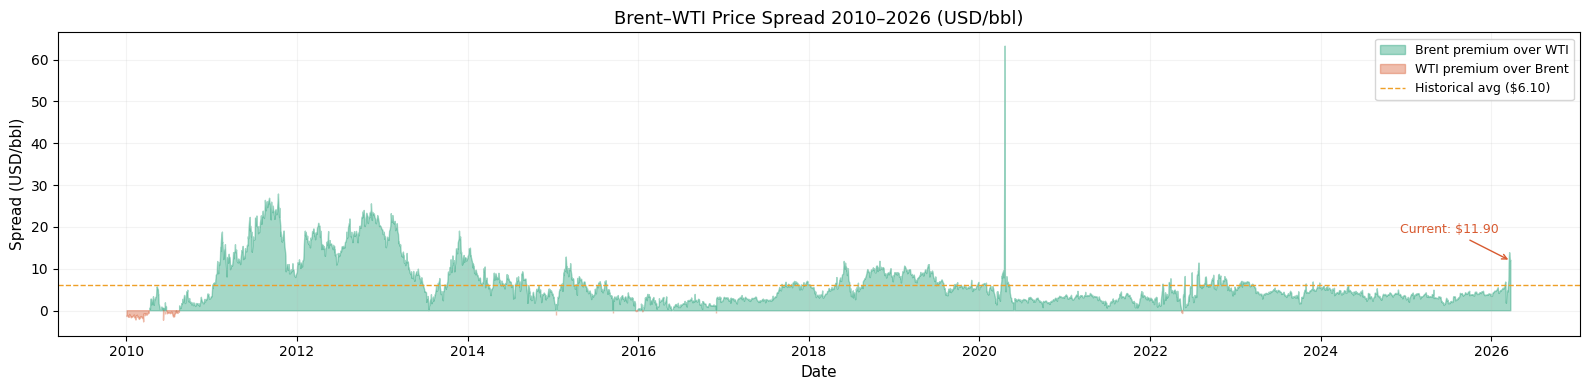

Chart 2 saved.


In [5]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.fill_between(master.index, master['brent_wti_spread'],
                where=master['brent_wti_spread'] >= 0,
                color=C_GREEN, alpha=0.4, label='Brent premium over WTI')
ax.fill_between(master.index, master['brent_wti_spread'],
                where=master['brent_wti_spread'] < 0,
                color=C_CORAL, alpha=0.4, label='WTI premium over Brent')

ax.axhline(master['brent_wti_spread'].mean(), color=C_AMBER,
           linestyle='--', linewidth=1, 
           label=f"Historical avg (${master['brent_wti_spread'].mean():.2f})")

# Annotate current spread
latest_spread = master['brent_wti_spread'].iloc[-1]
ax.annotate(f'Current: ${latest_spread:.2f}',
            xy=(master.index[-1], latest_spread),
            xytext=(-80, 20), textcoords='offset points',
            fontsize=9, color=C_CORAL,
            arrowprops=dict(arrowstyle='->', color=C_CORAL))

ax.set_title('Brent–WTI Price Spread 2010–2026 (USD/bbl)', fontsize=13)
ax.set_ylabel('Spread (USD/bbl)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('data/chart2_spread.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

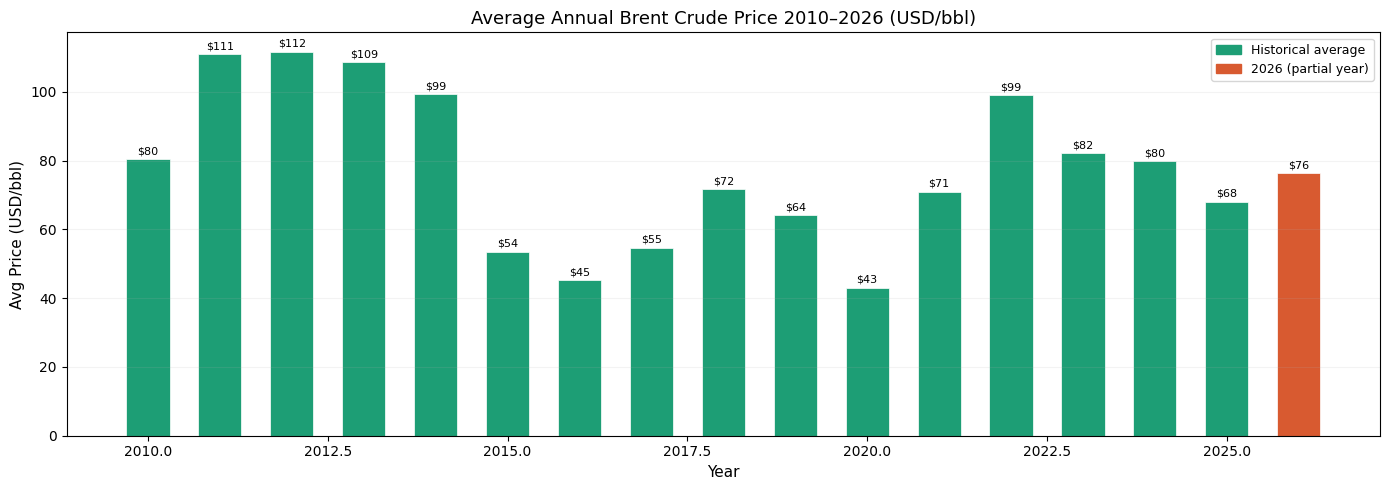

Chart 3 saved.


In [6]:
yearly = master['brent_price'].resample('YE').mean().round(2)

fig, ax = plt.subplots(figsize=(14, 5))

colors = [C_CORAL if yr.year == 2026 else C_GREEN for yr in yearly.index]
bars = ax.bar(yearly.index.year, yearly.values, color=colors, 
              width=0.6, edgecolor='white', linewidth=0.5)

# Add value labels on top of bars
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'${val:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Average Annual Brent Crude Price 2010–2026 (USD/bbl)', fontsize=13)
ax.set_ylabel('Avg Price (USD/bbl)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.grid(True, alpha=0.15, axis='y')

# Legend
green_patch = mpatches.Patch(color=C_GREEN, label='Historical average')
coral_patch = mpatches.Patch(color=C_CORAL, label='2026 (partial year)')
ax.legend(handles=[green_patch, coral_patch], fontsize=9)

plt.tight_layout()
plt.savefig('data/chart3_yearly_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

In [7]:
print("=" * 45)
print("  BRENT CRUDE — KEY STATISTICS")
print("=" * 45)

pre_2026 = master[master.index.year < 2026]['brent_price']
yr_2026  = master[master.index.year == 2026]['brent_price']

print(f"\nFull history (2010–2026)")
print(f"  All-time high : ${master['brent_price'].max():.2f}/bbl")
print(f"  All-time low  : ${master['brent_price'].min():.2f}/bbl")
print(f"  Overall avg   : ${master['brent_price'].mean():.2f}/bbl")

print(f"\nPre-2026 (2010–2025)")
print(f"  Average price : ${pre_2026.mean():.2f}/bbl")
print(f"  Max price     : ${pre_2026.max():.2f}/bbl")
print(f"  Min price     : ${pre_2026.min():.2f}/bbl")

print(f"\n2026 so far")
print(f"  Average price : ${yr_2026.mean():.2f}/bbl")
print(f"  Max price     : ${yr_2026.max():.2f}/bbl")
print(f"  Current price : ${master['brent_price'].iloc[-1]:.2f}/bbl")

print(f"\nBrent-WTI Spread")
print(f"  Historical avg spread : ${master['brent_wti_spread'].mean():.2f}/bbl")
print(f"  Current spread        : ${master['brent_wti_spread'].iloc[-1]:.2f}/bbl")
print(f"  Max ever spread       : ${master['brent_wti_spread'].max():.2f}/bbl")
print("=" * 45)

  BRENT CRUDE — KEY STATISTICS

Full history (2010–2026)
  All-time high : $127.98/bbl
  All-time low  : $19.33/bbl
  Overall avg   : $77.45/bbl

Pre-2026 (2010–2025)
  Average price : $77.47/bbl
  Max price     : $127.98/bbl
  Min price     : $19.33/bbl

2026 so far
  Average price : $76.38/bbl
  Max price     : $112.19/bbl
  Current price : $102.22/bbl

Brent-WTI Spread
  Historical avg spread : $6.10/bbl
  Current spread        : $11.90/bbl
  Max ever spread       : $63.20/bbl
